In [18]:

import numpy as np
import skfuzzy as fuzz
import matplotlib.pyplot as plt
# Configure matplotlib for better display
plt.rcParams['figure.figsize'] = [10, 5]
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# 1. Crisp Sets vs. Fuzzy Sets

## Exercise 1.1: Crisp vs. Fuzzy Tallness Ge

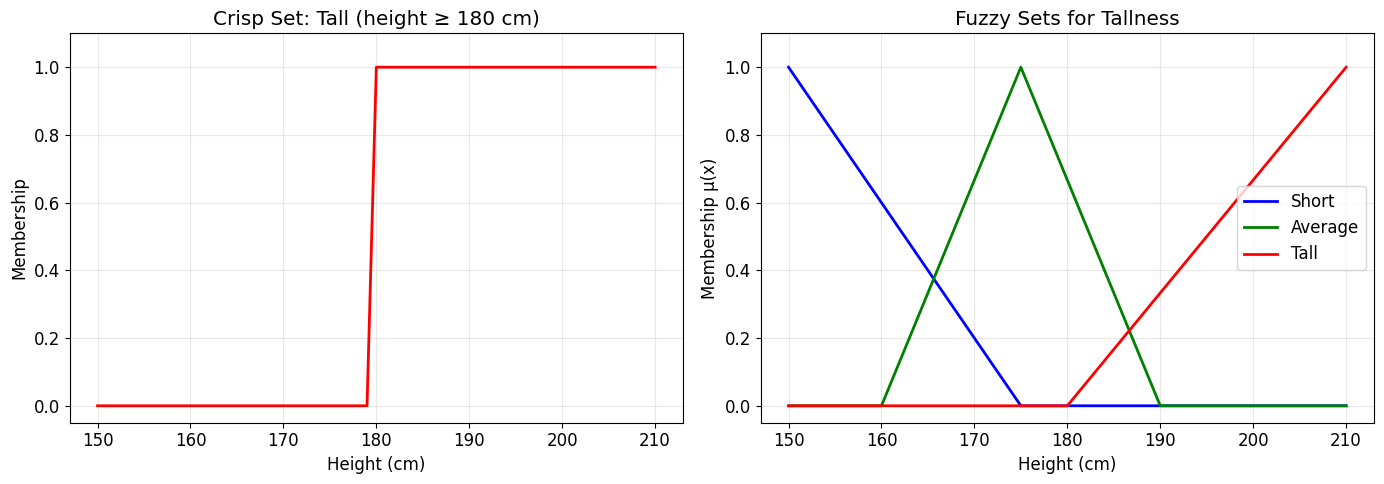

A person who is 184 cm tall:
 μ_average(184) = 0.40
 μ_tall(184) = 0.13
 → Partial membership in MULTIPLE sets simultaneously.


In [19]:
# Universe of discourse: height in cm
x_height = np.arange(150, 211, 1)

# --- Crisp set: tall if height >= 180 ---
crisp_tall = np.where(x_height >= 180, 1.0, 0.0)

# --- Fuzzy sets ---
short = fuzz.trimf(x_height, [150, 150, 175])
# TODO: create here the "average" and "tall" sets
average = fuzz.trimf(x_height, [160, 175, 190])
tall = fuzz.trimf(x_height, [180, 210, 210])


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
# Crisp
ax1.plot(x_height, crisp_tall, 'r-', linewidth=2)
ax1.set_title('Crisp Set: Tall (height ≥ 180 cm)')
ax1.set_xlabel('Height (cm)')
ax1.set_ylabel('Membership')
ax1.set_ylim(-0.05, 1.1)
# Fuzzy
ax2.plot(x_height, short, 'b-', linewidth=2, label='Short')
ax2.plot(x_height, average, 'g-', linewidth=2, label='Average')
ax2.plot(x_height, tall, 'r-', linewidth=2, label='Tall')
ax2.set_title('Fuzzy Sets for Tallness')
ax2.set_xlabel('Height (cm)')
ax2.set_ylabel('Membership μ(x)')
ax2.set_ylim(-0.05, 1.1)
ax2.legend()
plt.tight_layout()
plt.show()
# Demonstrate partial membership
height = 184
mu_avg = fuzz.interp_membership(x_height, average, height)
mu_tall = fuzz.interp_membership(x_height, tall, height)
# TODO: compute here the membership value for "tall"
print(f"A person who is {height} cm tall:")
print(f" μ_average({height}) = {mu_avg:.2f}")
print(f" μ_tall({height}) = {mu_tall:.2f}")
print(f" → Partial membership in MULTIPLE sets simultaneously.")

# 2. Common Membership Functions

## Exercise 2.1: Plot All Four Membership Function Types

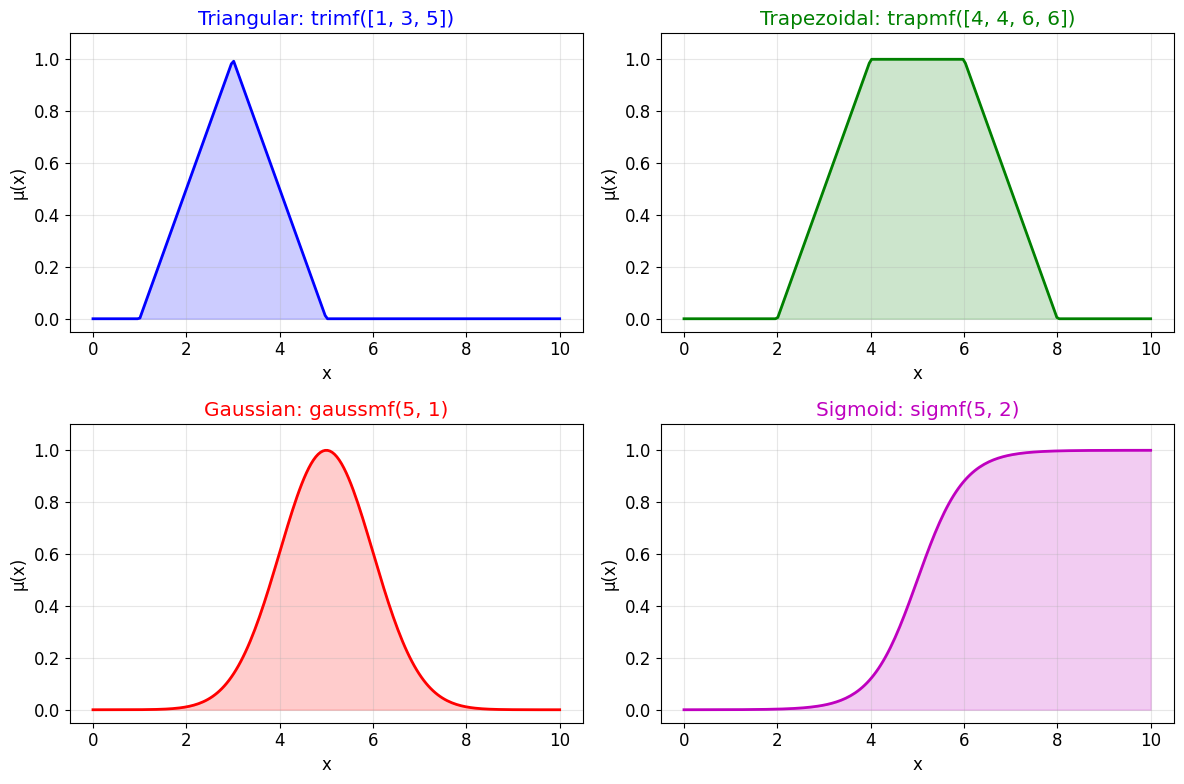

In [20]:
x = np.linspace(0, 10, 200)
# Triangular: peak at 3
# TODO: create here a triangular membership function
mf_tri = fuzz.trimf(x, [1, 3, 5])

# Trapezoidal: plateau from 4 to 6
# TODO: create here a trapezoidal membership function
mf_trap = fuzz.trapmf(x, [2, 4, 6, 8])

# Gaussian: centred at 5, sigma=1
# TODO: create here a gaussian membership function
mf_gauss = fuzz.gaussmf(x, 5, 1)

# Sigmoid: inflection at 5, slope=2 (positive = rising)
# TODO: create here a sigmoidal membership function
mf_sigmoid = fuzz.sigmf(x, 5, 2)


fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0, 0].plot(x, mf_tri, 'b-', linewidth=2)
axes[0, 0].set_title('Triangular: trimf([1, 3, 5])', color='b')
axes[0, 0].fill_between(x, mf_tri, alpha=0.2, color='b')

# TODO: code here to visualise the other 3 membership functions
axes[0, 1].plot(x, mf_trap, 'g-', linewidth=2)
axes[0, 1].set_title('Trapezoidal: trapmf([4, 4, 6, 6])', color='g')
axes[0, 1].fill_between(x, mf_trap, alpha=0.2, color='g')

axes[1, 0].plot(x, mf_gauss, 'r-', linewidth=2)
axes[1, 0].set_title('Gaussian: gaussmf(5, 1)', color='r')
axes[1, 0].fill_between(x, mf_gauss, alpha=0.2, color='r')  

axes[1, 1].plot(x, mf_sigmoid, 'm-', linewidth=2)
axes[1, 1].set_title('Sigmoid: sigmf(5, 2)', color='m')
axes[1, 1].fill_between(x, mf_sigmoid, alpha=0.2, color='m')

for ax in axes.flat:
    ax.set_xlabel('x')
    ax.set_ylabel('μ(x)')
    ax.set_ylim(-0.05, 1.1)
plt.tight_layout()
plt.show()


## Exercise 2.2: The Dapping Example — Defining Linguistic Variables


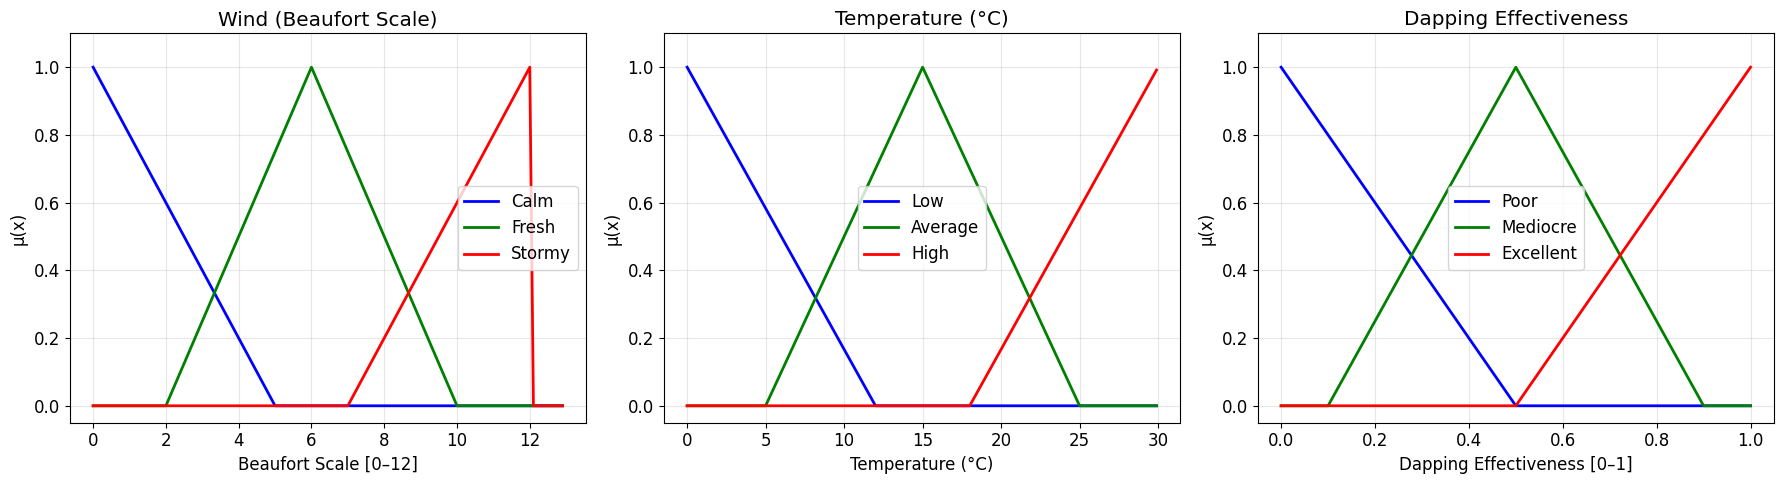

In [21]:
# --- Define universes of discourse ---
x_wind = np.arange(0, 13, 0.1) # Beaufort scale 0-12

# TODO: code here the universes of discurse for temperature and dapping effectiveness
x_temp = np.arange(0, 30, 0.1) # Temperature in °C
x_dapping = np.arange(0, 1.01, 0.01) # Dapping effectiveness [0-1]

# --- Wind membership functions ---
wind_calm = fuzz.trimf(x_wind, [0, 0, 5])
wind_fresh = fuzz.trimf(x_wind, [2, 6, 10])
wind_stormy = fuzz.trimf(x_wind, [7, 12, 12])
# --- Temperature membership functions ---
# TODO: code the temperature membership functions here
temp_low = fuzz.trimf(x_temp, [0, 0, 12])
temp_average = fuzz.trimf(x_temp, [5, 15, 25])
temp_high = fuzz.trimf(x_temp, [18, 30, 30])
# --- Dapping membership functions ---
# TODO: code the dapping membership functions here
dapping_poor = fuzz.trimf(x_dapping, [0, 0, 0.5])
dapping_mediocre = fuzz.trimf(x_dapping, [0.10, 0.5, 0.90])
dapping_excellent = fuzz.trimf(x_dapping, [0.5, 1, 1])
# --- Plot ---
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
# Wind
ax1.plot(x_wind, wind_calm, 'b-', linewidth=2, label='Calm')
ax1.plot(x_wind, wind_fresh, 'g-', linewidth=2, label='Fresh')
ax1.plot(x_wind, wind_stormy, 'r-', linewidth=2, label='Stormy')
ax1.set_title('Wind (Beaufort Scale)')
ax1.set_xlabel('Beaufort Scale [0–12]')
ax1.set_ylabel('μ(x)')
ax1.legend()

# Temperature
# TODO: code here the figure for temperature
ax2.plot(x_temp, temp_low, 'b-', linewidth=2, label='Low')
ax2.plot(x_temp, temp_average, 'g-', linewidth=2, label='Average')
ax2.plot(x_temp, temp_high, 'r-', linewidth=2, label='High')
ax2.set_title('Temperature (°C)')
ax2.set_xlabel('Temperature (°C)')
ax2.set_ylabel('μ(x)')
ax2.legend()

# Dapping
# TODO: code here the figure for dapping
ax3.plot(x_dapping, dapping_poor, 'b-', linewidth=2, label='Poor')
ax3.plot(x_dapping, dapping_mediocre, 'g-', linewidth=2, label='Mediocre')
ax3.plot(x_dapping, dapping_excellent, 'r-', linewidth=2, label='Excellent')
ax3.set_title('Dapping Effectiveness')
ax3.set_xlabel('Dapping Effectiveness [0–1]')
ax3.set_ylabel('μ(x)')
ax3.legend()

for ax in [ax1, ax2, ax3]:
    ax.set_ylim(-0.05, 1.1)
plt.tight_layout()
plt.show()

## Exercise 2.3: Computing Membership Degrees

In [22]:
# Crisp inputs
wind_val = 8
temp_val = 10

# Fuzzify wind
mu_calm = fuzz.interp_membership(x_wind, wind_calm, wind_val)
mu_fresh = fuzz.interp_membership(x_wind, wind_fresh, wind_val)
mu_stormy = fuzz.interp_membership(x_wind, wind_stormy, wind_val)

# Fuzzify temperature
# TODO: code the temperature fuzzification here
mu_low = fuzz.interp_membership(x_temp, temp_low, temp_val)
mu_average = fuzz.interp_membership(x_temp, temp_average, temp_val)
mu_high = fuzz.interp_membership(x_temp, temp_high, temp_val)


print(f"Fuzzification for wind = {wind_val}, temperature = {temp_val}")
print(f"{'─' * 45}")
print(f" μ_calm({wind_val}) = {mu_calm:.4f}")
print(f" μ_fresh({wind_val}) = {mu_fresh:.4f}")
print(f" μ_stormy({wind_val}) = {mu_stormy:.4f}")
print()
print(f" μ_low({temp_val}) = {mu_low:.4f}")
print(f" μ_average({temp_val}) = {mu_average:.4f}")
print(f" μ_high({temp_val}) = {mu_high:.4f}")

Fuzzification for wind = 8, temperature = 10
─────────────────────────────────────────────
 μ_calm(8) = 0.0000
 μ_fresh(8) = 0.5000
 μ_stormy(8) = 0.2000

 μ_low(10) = 0.1667
 μ_average(10) = 0.5000
 μ_high(10) = 0.0000


# Hedges — Fuzzy Set Modifiers

In [23]:
def hedge_very(mu):
 """Very: μ^2 (concentration)"""
 return mu ** 2

# TODO: code all the remaining hedge functions here
def hedge_extremely(mu):
    """Extremely: μ^3 (extreme concentration)"""
    return mu ** 3

def hedge_very_very(mu):
    """Very Very: μ^4 (extreme concentration)"""
    return mu ** 4

def hedge_slightly(mu):
    """Slightly:  μ^1.7 """
    return mu ** 1.7

def hedge_a_little(mu):
    """Little: μ^1.3"""
    return mu ** 1.3

def hedge_more_or_less(mu):
    """More or Less: √μA(x)"""
    return np.sqrt(mu)

def hedge_somewhat(mu):
    """Somewhat: √3 μA(x)"""
    return np.cbrt(mu)
    

def hedge_indeed(mu):
    """"Indeed: if μ < 0.5 then 2μ^2 else 1 - 2(1-μ)^2"""
    return np.where(mu < 0.5, 2 * mu ** 2, 1 - 2 * (1 - mu) ** 2)
    

def hedge_not(mu):
    """Not: 1 - μA(x)"""
    return 1 - mu

## Tip 1: use NumPy's "where" function to code
## the "hedge_indeed" function
## Tip 2: see the Exercise 3.2 code cell for the 
## names of the functions

## Exercise 3.2: Visualise Hedge Effects

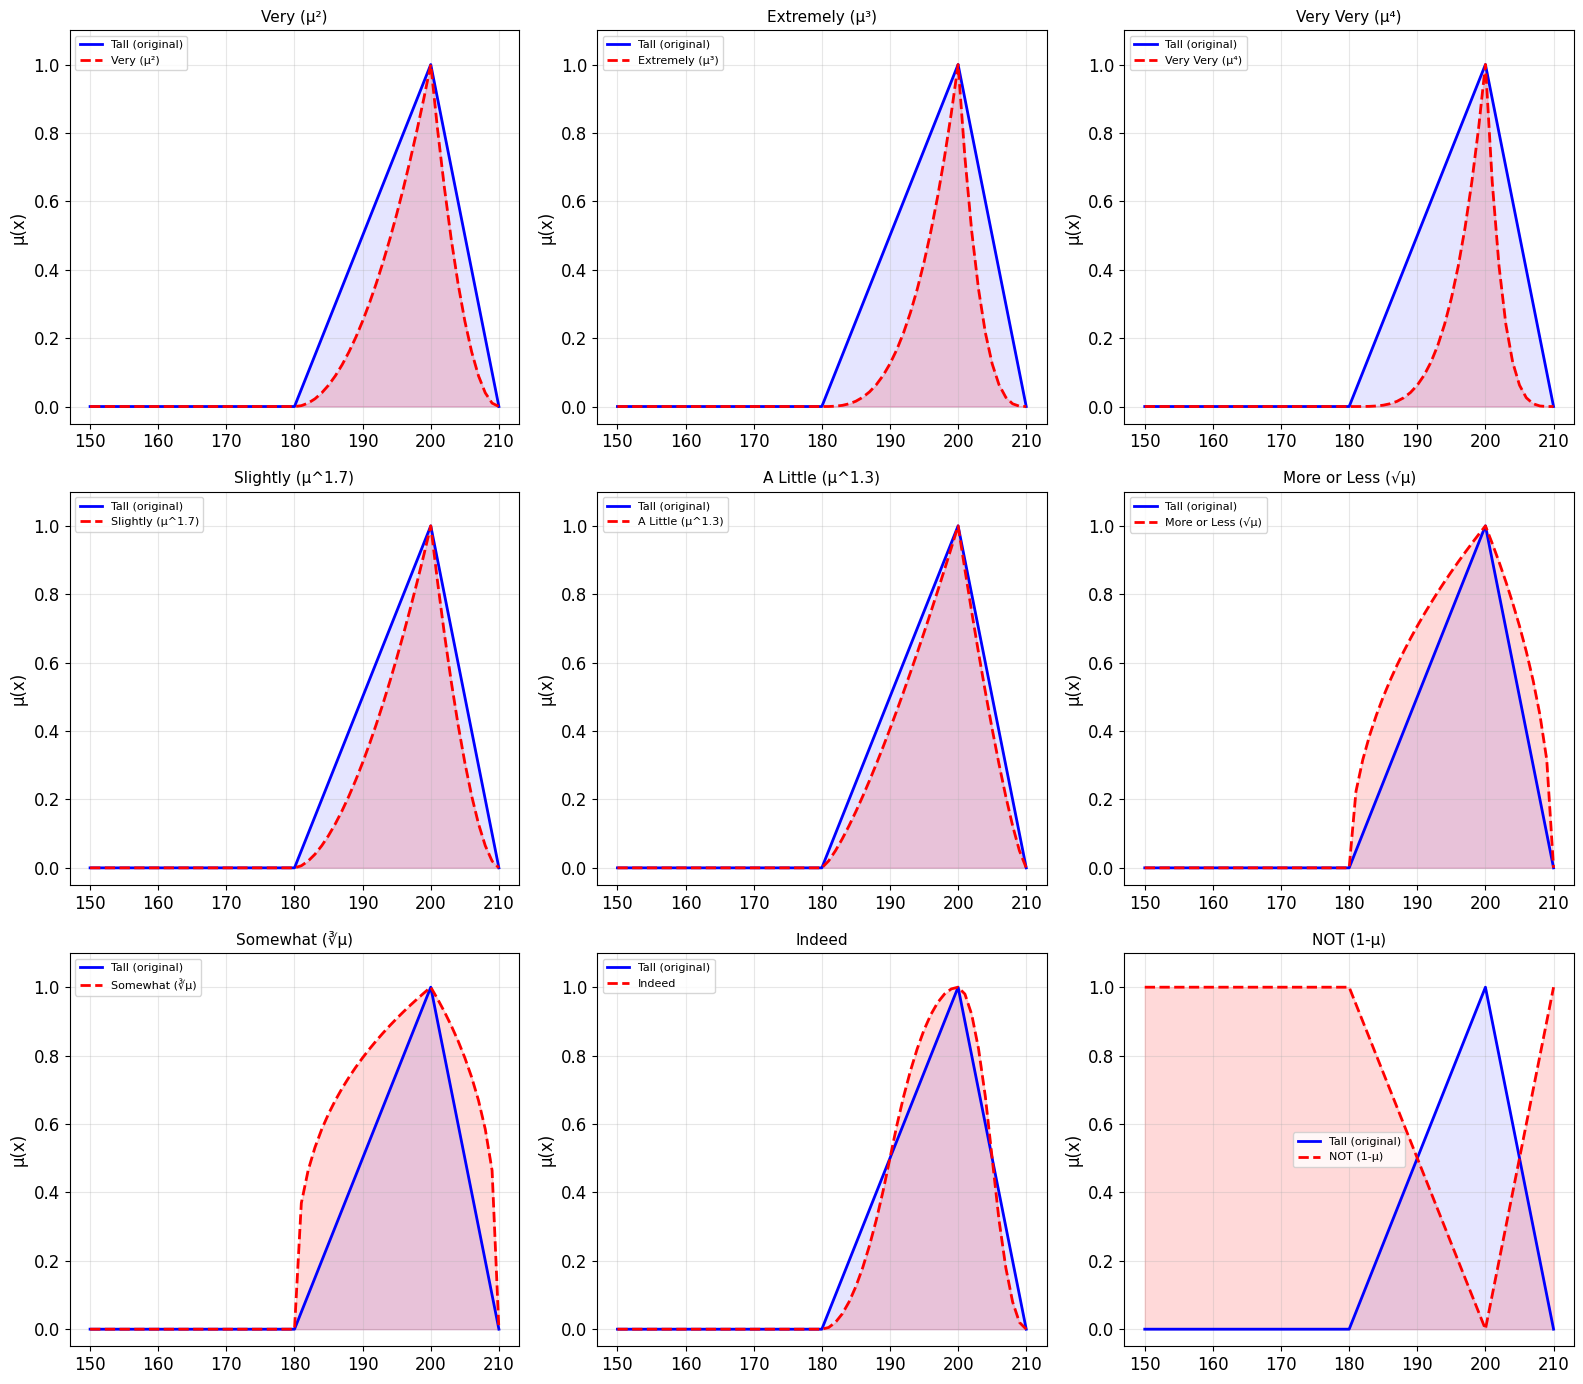

In [24]:
x_height = np.arange(150, 211, 1)
tall = fuzz.trimf(x_height, [180, 200, 210])
hedges = {
 'Very (μ²)': hedge_very,
 'Extremely (μ³)': hedge_extremely,
 'Very Very (μ⁴)': hedge_very_very,
 'Slightly (μ^1.7)': hedge_slightly,
 'A Little (μ^1.3)': hedge_a_little,
 'More or Less (√μ)': hedge_more_or_less,
 'Somewhat (∛μ)': hedge_somewhat,
 'Indeed': hedge_indeed,
 'NOT (1-μ)': hedge_not,
}
fig, axes = plt.subplots(3, 3, figsize=(16, 14))
for ax, (name, func) in zip(axes.flat, hedges.items()):
 hedged = func(tall)
 ax.plot(x_height, tall, 'b-', linewidth=2, label='Tall (original)')
 ax.plot(x_height, hedged, 'r--', linewidth=2, label=name)
 ax.fill_between(x_height, tall, alpha=0.1, color='blue')
 ax.fill_between(x_height, hedged, alpha=0.15, color='red')
 ax.set_title(name, fontsize=11)
 ax.set_ylabel('μ(x)')
 ax.set_ylim(-0.05, 1.1)
 ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## Exercise 3.3: Hedge Computations for Practice

In [27]:
mu = 0.86
print(f"Slide verification (μ = {mu}):")
print(f" Very: {hedge_very(mu):.4f} (expected: 0.7396)")
print(f" Extremely: {hedge_extremely(mu):.4f} (expected: 0.6361)")
print(f" Very Very: {hedge_very_very(mu):.4f} (expected: 0.5470)")
print(f" More or Less: {hedge_more_or_less(mu):.4f} (expected: 0.9274)")
print()

# Task: Verify these computations; then for the the dapping example, calculate the hedged membership
# values for ( ), ( ), and ( )

# TODO: code here to compute the hedged membership values for the
# dapping example for μ_stormy(8)
mu = 0.5
print(f"Dapping example (μ_stormy(8) = {mu}):")
print(f" Extremely stormy: {hedge_extremely(mu):.4f} → μ^3 = 0.125")
print(f" Slightly stormy: {hedge_slightly(mu):.4f} → μ^1.7 ≈ 0.307 ")
print(f" Very stormy: {hedge_very(mu):.4f} → μ^4 = 0.25")
print()

mu = 0.3
print(f"Dapping example (μ_low(10) = {mu}):")
print(f" Very low: {hedge_very(mu):.4f} → μ^2 = 0.09")
print()
mu = 0.7
print(f"Dapping example (μ_average(10) = {mu}):")
print(f" More or less avg: {hedge_more_or_less(mu):.4f} → √0.7 ≈ 0.8367")


Slide verification (μ = 0.86):
 Very: 0.7396 (expected: 0.7396)
 Extremely: 0.6361 (expected: 0.6361)
 Very Very: 0.5470 (expected: 0.5470)
 More or Less: 0.9274 (expected: 0.9274)

Dapping example (μ_stormy(8) = 0.5):
 Extremely stormy: 0.1250 → μ^3 = 0.125
 Slightly stormy: 0.3078 → μ^1.7 ≈ 0.307 
 Very stormy: 0.2500 → μ^4 = 0.25

Dapping example (μ_low(10) = 0.3):
 Very low: 0.0900 → μ^2 = 0.09

Dapping example (μ_average(10) = 0.7):
 More or less avg: 0.8367 → √0.7 ≈ 0.8367


# 4. Fuzzy Set Operations
